# Sales Prediction Using Python

Objective: Predict product sales using advertising data.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
df = pd.read_csv("advertising.csv")

print(df.head())
print(df.info())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         10 non-null     float64
 1   Radio      10 non-null     float64
 2   Newspaper  10 non-null     float64
 3   Sales      10 non-null     float64
dtypes: float64(4)
memory usage: 452.0 bytes
None


              TV      Radio  Newspaper      Sales
count   10.00000  10.000000  10.000000  10.000000
mean   101.89000  28.110000  43.280000  12.080000
std     84.89945  17.836071  26.850649   5.090034
min      8.60000   2.100000   1.000000   4.800000
25%     24.02500  13.000000  21.775000   9.575000
50%     88.85000  35.300000  51.750000  11.200000
75%    173.47500  40.800000  66.525000  13.125000
max    230.10000  48.900000  75.000000  22.100000


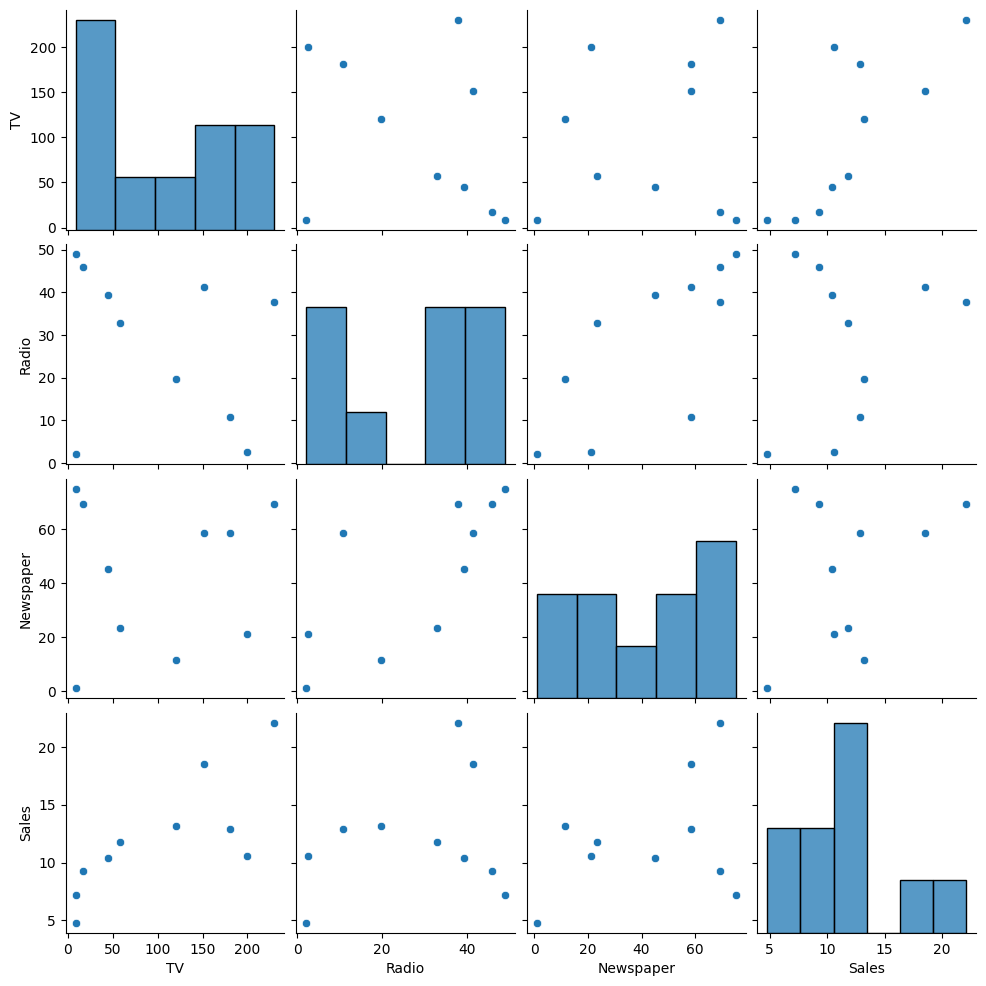

In [14]:
print(df.describe())

sns.pairplot(df)
plt.show()

In [15]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2.647769402806265
MSE : 13.201451790963391
RMSE: 3.6333802155793427
R2 Score: -0.6838586468065546


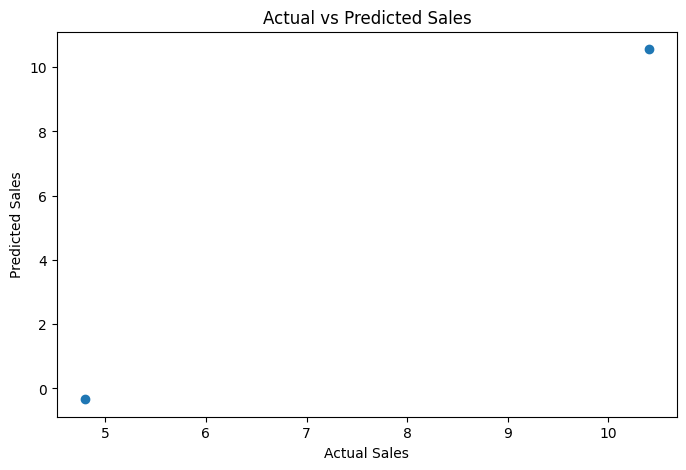

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

     Feature  Coefficient
0         TV     0.074687
1      Radio     0.302915
2  Newspaper    -0.069256


In [22]:
new_data = [[230.1, 37.8, 69.2]]

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 22.29817717458586


C:\Users\malay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
